In [27]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("emails.csv")

In [4]:
df.head()

,Text,Spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [5]:
df.shape

(5728, 2)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    5728 non-null   object
 1   Spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [21]:
df.dtypes

Text    object
Spam     int64
dtype: object

In [22]:
df.isnull().sum()

Text    0
Spam    0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(33)

In [25]:
df['Spam'].value_counts(normalize=True)*100

Spam
0    76.117318
1    23.882682
Name: proportion, dtype: float64

In [26]:
df[df['Spam']==1]['Text'].head()

0    Subject: naturally irresistible your corporate...
1    Subject: the stock trading gunslinger  fanny i...
2    Subject: unbelievable new homes made easy  im ...
3    Subject: 4 color printing special  request add...
4    Subject: do not have money , get software cds ...
Name: Text, dtype: object

Text(0.5, 1.0, 'spam vs ham distribution')

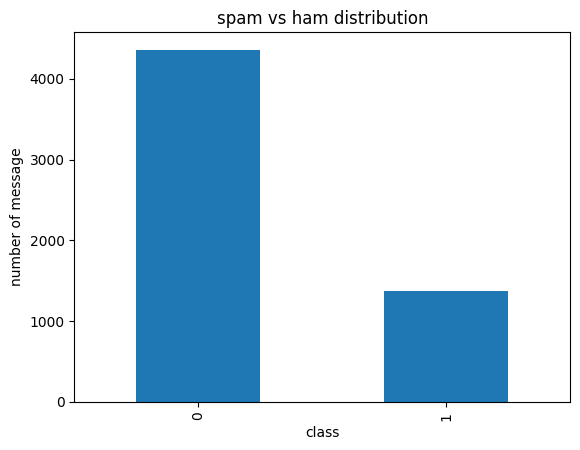

In [30]:
df['Spam'].value_counts().plot(kind='bar')
plt.xlabel('class')
plt.ylabel('number of message')
plt.title('spam vs ham distribution')

In [45]:
df['text_length']=df['Text'].str.len()

In [46]:
text_length

0       1484
1        598
2        448
3        500
4        235
        ... 
5723    1189
5724    1167
5725    2131
5726    1060
5727    2331
Name: Text, Length: 5728, dtype: int64

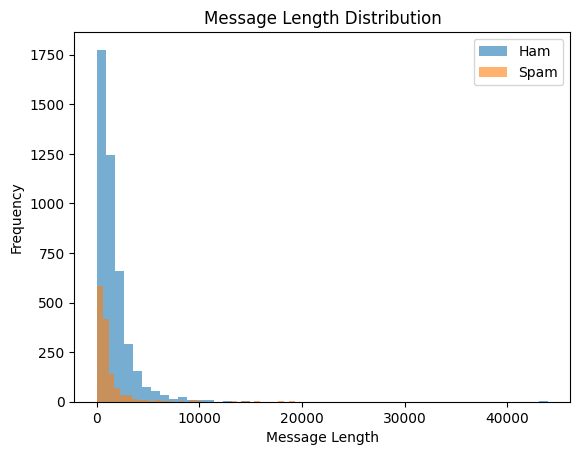

In [47]:
plt.hist(
    df[df['Spam'] == 0]['text_length'],
    bins=50,
    alpha=0.6,
    label='Ham'
)

plt.hist(
    df[df['Spam'] == 1]['text_length'],
    bins=50,
    alpha=0.6,
    label='Spam'
)

plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.title('Message Length Distribution')
plt.legend()

plt.show()

In [48]:
df.groupby('Spam')['text_length'].agg(['count','mean','median','min','max'])

,count,mean,median,min,max
Spam,,,,,
0,4360,1631.918119,1122.0,13,43952
1,1368,1317.257310,693.5,18,28432


In [49]:
df.nlargest(10, 'text_length')[['Spam', 'text_length']]

,Spam,text_length
2650,0,43952
1380,0,43937
2338,0,31055
536,1,28432
2560,0,27965
151,1,22476
126,1,19174
49,1,18999
461,1,18776
1594,0,18375


In [51]:
df['Spam'].unique()

array([1, 0])

In [52]:
df["Spam"].nunique()

2

In [53]:
df.isnull().sum()

Text           0
Spam           0
text_length    0
dtype: int64

In [56]:
duplicates=df[df.duplicated(keep=False)]

In [58]:
duplicates.shape

(66, 3)

In [59]:
duplicates['Spam'].value_counts()

Spam
0    66
Name: count, dtype: int64

In [60]:
df['Text'].duplicated().sum()

np.int64(33)

In [61]:
display(
    df[df['Spam'] == 0][['Text', 'Spam']].sample(5, random_state=42)
)

,Text,Spam
1547,Subject: interview schedule for jinbaek kim i...,0
2730,"Subject: re : wednesday meeting eric , i thi...",0
4843,Subject: re : london research group i ' d do ...,0
2856,"Subject: re : congratulations vince , thanks ...",0
3804,Subject: osman sezgen steve kromer is request...,0


In [62]:
display(
    df[df['Spam'] == 1][['Text', 'Spam']].sample(5, random_state=42)
)

,Text,Spam
427,Subject: re : education opportunity we spoke a...,1
1087,Subject: custom logos and identities from us ...,1
668,Subject: trusted savings on prescription drugs...,1
572,"Subject: ouur medz hello , welcome to pharmon...",1
115,Subject: fw : i ' m unwell . in 1839 not at a...,1
